## Segmentación ROI + K-Means

In [50]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import os              
import time            
import csv             
import cv2             
import numpy as np     
from glob import glob  
import matplotlib.pyplot as plt  

#### DEFINICIÓN DE RUTAS

In [37]:
# Directorio de imágenes de entrenamiento
TRAIN_DIR = r"H:\MaestriaUIDE\final_1\Data_1"

# Directorio de imágenes de prueba
TEST_DIR  = r"H:\MaestriaUIDE\final_1\Data"

# Carpeta donde se guardarán los resultados
OUT_DIR   = r"H:\MaestriaUIDE\final_1\out_kmeans_metodo1"

#### PARÁMETROS DEL EXPERIMENTO

In [38]:
K = 4                # Número de clusters que se usarán en K-means
ROI_SCALE = 0.5      # Escala para reducir tamaño en watershed (acelera proceso)

MAX_SAMPLES = 500_000   # Máximo total de píxeles para entrenar
PER_IMAGE_CAP = 8_000   # Máximo número de píxeles por imagen
SEED = 42               # Semilla para reproducibilidad

#### PARÁMETROS INTERNOS DE K-MEANS

In [39]:
KMEANS_ATTEMPTS = 3   # Número de veces que se ejecuta K-means
KMEANS_MAXITER = 40   # Máximo número de iteraciones
KMEANS_EPS = 0.5      # Criterio de convergencia

#### VISUALIZACIÓN

In [40]:
SHOW_EXAMPLES = 2  # Número de imágenes de ejemplo a mostrar
os.makedirs(OUT_DIR, exist_ok=True)  # Crear carpeta si no existe

#### FUNCIÓN PARA LISTAR IMÁGENES

In [41]:
def list_imgs(folder):
    # Busca imágenes con diferentes extensiones
    return sorted(
        glob(os.path.join(folder, "*.tif")) +
        glob(os.path.join(folder, "*.tiff")) +
        glob(os.path.join(folder, "*.png")) +
        glob(os.path.join(folder, "*.jpg")) +
        glob(os.path.join(folder, "*.jpeg"))
    )

#### FUNCIÓN PARA ASEGURAR ESCALA DE GRISES UINT8

In [42]:
def to_uint8_gray(img):
    if img is None:
        return None

    # Si la imagen es a color la convierte a escala de grises
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Si no es uint8 la normaliza al rango [0,255]
    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return img

#### FUNCIÓN ROI – SEGMENTACIÓN CON WATERSHED

Reduce resolución (optimiza tiempo)
Aplica filtro Gaussiano
Calcula gradiente Sobel
Umbraliza con Otsu
Limpia con morfología
Aplica Distance Transform
Segmenta con Watershed
Se queda con el componente más grande
Reescala al tamaño original
Esto permite aislar la región anatómica o estructural de interés.

In [43]:
#Imagen ROI
def roi_mask_seq_method1(img_in, scale=0.5):
    img = to_uint8_gray(img_in)
    if img is None:
        return None

    H, W = img.shape
    # Downscale (acelera muchísimo distTransform + watershed)
    sW = max(64, int(W * scale))
    sH = max(64, int(H * scale))
    small = cv2.resize(img, (sW, sH), interpolation=cv2.INTER_AREA)

    blur = cv2.GaussianBlur(small, (5, 5), 0)

    # Gradiente Sobel
    sobelx = cv2.Sobel(blur, cv2.CV_32F, 1, 0, ksize=3)
    sobely = cv2.Sobel(blur, cv2.CV_32F, 0, 1, ksize=3)
    gradient = cv2.magnitude(sobelx, sobely)
    gradient = cv2.convertScaleAbs(gradient)

    # Otsu
    _, binary = cv2.threshold(gradient, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morfología (como en tu notebook)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_morph = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    opening2 = cv2.morphologyEx(mask_morph, cv2.MORPH_OPEN, kernel, iterations=1)

    # Dist transform + sure fg
    dist_transform = cv2.distanceTransform(opening2, cv2.DIST_L2, 5)
    if dist_transform.max() == 0:
        # máscara vacía
        mask_small = np.zeros_like(opening2, dtype=np.uint8)
    else:
        _, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
        sure_fg = np.uint8(sure_fg)

        # Marcadores
        _, markers = cv2.connectedComponents(sure_fg)
        markers = markers + 1

        # Watershed requiere 3 canales
        img_color = cv2.cvtColor(small, cv2.COLOR_GRAY2BGR)
        markers = cv2.watershed(img_color, markers)

        mask_small = np.zeros_like(small, dtype=np.uint8)
        mask_small[markers > 1] = 255

    # Quedarse con el componente más grande (para evitar “puntitos”)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_small, 8)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        clean = np.zeros_like(mask_small)
        clean[labels == largest] = 255
        mask_small = clean

    # Upscale a tamaño original
    mask = cv2.resize(mask_small, (W, H), interpolation=cv2.INTER_NEAREST)

    # Un cierre suave final para asegurar solidez
    k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k2, iterations=1)

    return mask

#MUESTREO PIXELES ROI
def collect_roi_pixels_stream(train_paths, max_samples, per_image_cap, seed=42):
    rng = np.random.default_rng(seed)
    samples = []
    total = 0

    for p in train_paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        m = roi_mask_seq_method1(img, ROI_SCALE)
        if m is None:
            continue

        vals = img[m > 0].astype(np.float32)
        if vals.size == 0:
            continue

        take = min(per_image_cap, vals.size, max_samples - total)
        if take <= 0:
            break

        idx = rng.choice(vals.size, size=take, replace=False)
        samples.append(vals[idx])
        total += take

        if total >= max_samples:
            break

    if total == 0:
        raise ValueError("No se obtuvieron píxeles ROI. Revisa si mask_seq está quedando vacía.")

    return np.concatenate(samples).reshape(-1, 1)

#### ENTRENAMIENTO K-MEANS

In [44]:
def train_kmeans_1d(pixels, k):

    # Definir criterios de parada del algoritmo
    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        KMEANS_MAXITER,
        KMEANS_EPS
    )

    # Ejecutar K-means
    compactness, labels, centers = cv2.kmeans(
        pixels, k, None, criteria,
        KMEANS_ATTEMPTS,
        cv2.KMEANS_PP_CENTERS
    )

    labels = labels.flatten()
    centers = centers.flatten()

    # Calcular estadísticas de cada cluster
    stats = []
    for i in range(k):
        v = pixels[labels == i]
        if v.size == 0:
            continue
        stats.append((i, float(centers[i]), float(v.min()), float(v.max())))

    # Ordenar clusters por intensidad
    stats.sort(key=lambda x: x[1])

    return float(compactness), centers.astype(np.float32), stats

def assign_clusters_roi(img_gray, mask, centers):
    out = np.zeros_like(img_gray, dtype=np.uint8)
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return out

    vals = img_gray[ys, xs].astype(np.float32)
    d = np.abs(vals.reshape(-1, 1) - centers.reshape(1, -1))
    lab = np.argmin(d, axis=1).astype(np.uint8)

    scale = max(1, int(255 / (len(centers) + 1)))
    out[ys, xs] = (lab + 1) * scale
    return out

#### EJECUCIÓN PRINCIPAL

In [45]:
train_paths = list_imgs(TRAIN_DIR)
test_paths  = list_imgs(TEST_DIR)

print("Train images:", len(train_paths))
print("Test images :", len(test_paths))

Train images: 1
Test images : 350


#### MUESTREO ROI

In [46]:
t0 = time.time()
print("\n[1/4] Muestreando pixeles ROI...")

pixels = collect_roi_pixels_stream(
    train_paths,
    MAX_SAMPLES,
    PER_IMAGE_CAP,
    SEED
)

print("Pixeles ROI usados:", pixels.shape[0])
print("Tiempo sampling:", round(time.time() - t0, 2), "s")


[1/4] Muestreando pixeles ROI...
Pixeles ROI usados: 511
Tiempo sampling: 0.03 s


#### ENTRENAMIENTO K-MEANS

In [47]:
t1 = time.time()
print("\n[2/4] Entrenando K-means...")

compactness, centers, stats = train_kmeans_1d(pixels, K)

print("Compactness:", round(compactness, 2))
print("Tiempo entrenamiento:", round(time.time() - t1, 2), "s")


[2/4] Entrenando K-means...
Compactness: 77039.98
Tiempo entrenamiento: 0.0 s


#### TABLA DE RESULTADOS

Permite interpretar rangos de intensidad.

In [48]:
print("\nCluster | Center | Min | Max")
print("-" * 30)
for cid, c, mn, mx in stats:
    print(f"{cid:<7} | {c:>6.2f} | {mn:>3.0f} | {mx:>3.0f}")


Cluster | Center | Min | Max
------------------------------
2       |  82.72 |  22 | 115
0       | 149.05 | 116 | 165
1       | 180.90 | 166 | 199
3       | 218.01 | 200 | 241


#### VISUALIZACIÓN DE RESULTADOS


[3/4] CSV guardado: H:\MaestriaUIDE\final_1\out_kmeans_metodo1\clusters_maskseq_K4.csv

[4/4] Aplicando centros al TEST (solo ROI mask_seq) y guardando...


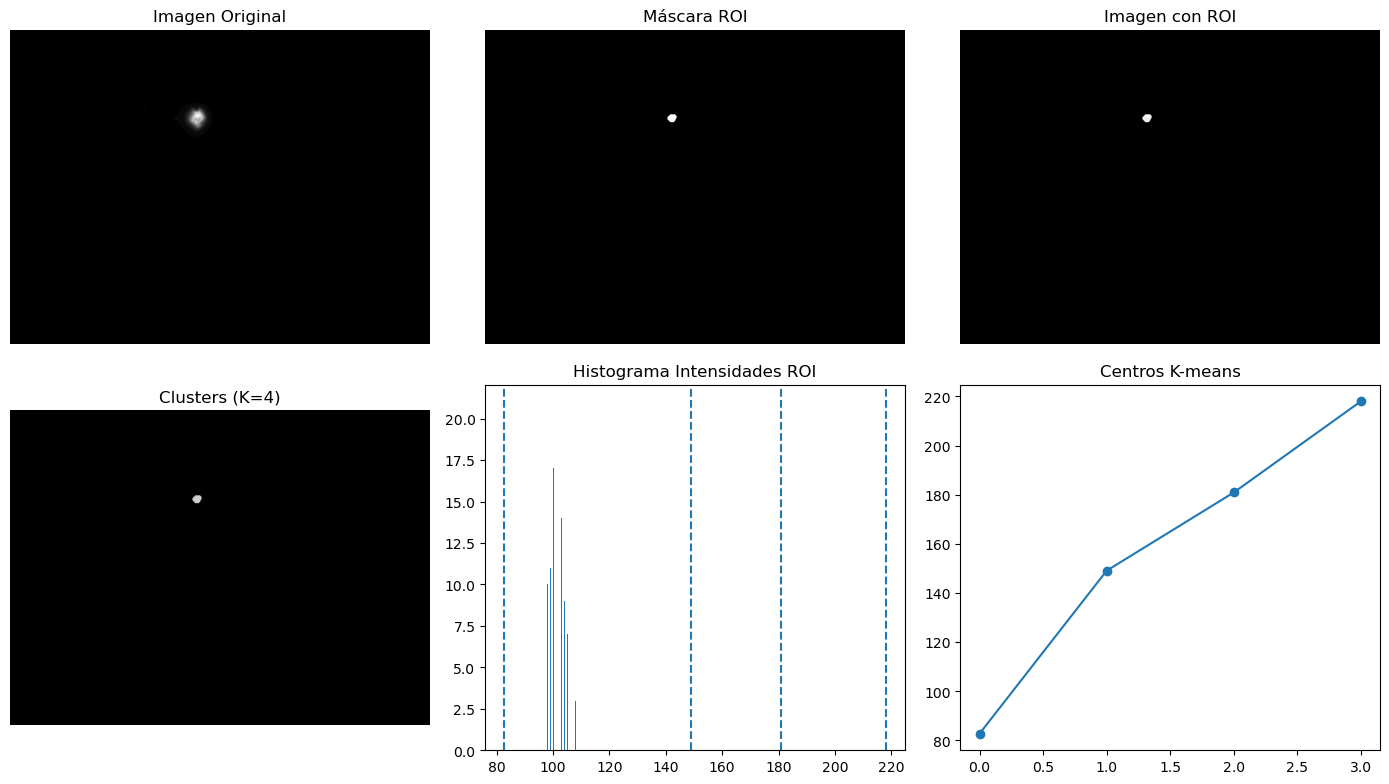

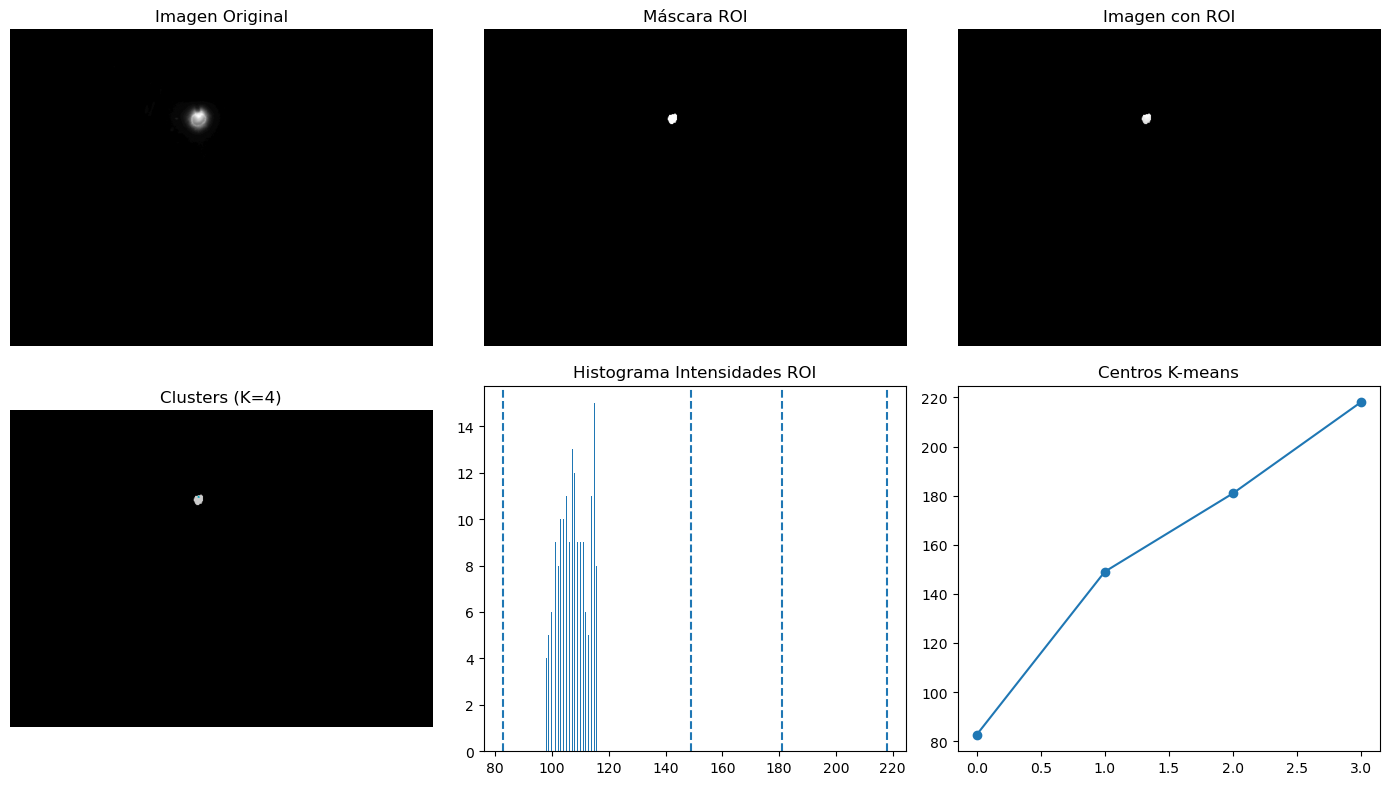

  Tiempo aplicar test: 5.57 s

✅ Terminado. Resultados en: H:\MaestriaUIDE\final_1\out_kmeans_metodo1
Tiempo total: 48.44 s


In [49]:
# Exportar CSV
csv_path = os.path.join(OUT_DIR, f"clusters_maskseq_K{K}.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["cluster_id", "center", "min", "max"])
    for cid, c, mn, mx in stats:
        w.writerow([cid, round(c, 3), round(mn, 3), round(mx, 3)])
print("\n[3/4] CSV guardado:", csv_path)

t2 = time.time()
print("\n[4/4] Aplicando centros al TEST (solo ROI mask_seq) y guardando...")
shown = 0
for p in test_paths:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    mask = roi_mask_seq_method1(img, ROI_SCALE)
    roi_only = cv2.bitwise_and(img, img, mask=mask)
    clusters_map = assign_clusters_roi(img, mask, centers)

    base = os.path.splitext(os.path.basename(p))[0]
    cv2.imwrite(os.path.join(OUT_DIR, f"{base}_roi.png"), roi_only)
    cv2.imwrite(os.path.join(OUT_DIR, f"{base}_clusters_K{K}.png"), clusters_map)

    if shown < SHOW_EXAMPLES:
        shown += 1

        plt.figure(figsize=(14,8))

        # Imagen original
        plt.subplot(2,3,1)
        plt.imshow(img, cmap="gray")
        plt.title("Imagen Original")
        plt.axis("off")

        # Máscara ROI
        plt.subplot(2,3,2)
        plt.imshow(mask, cmap="gray")
        plt.title("Máscara ROI")
        plt.axis("off")

        # ROI aplicado
        plt.subplot(2,3,3)
        plt.imshow(roi_only, cmap="gray")
        plt.title("Imagen con ROI")
        plt.axis("off")

        # Clusters
        plt.subplot(2,3,4)
        plt.imshow(clusters_map, cmap="nipy_spectral")
        plt.title(f"Clusters (K={K})")
        plt.axis("off")

        # Histograma ROI
        roi_vals = img[mask > 0]
        plt.subplot(2,3,5)
        plt.hist(roi_vals.flatten(), bins=50)
        plt.title("Histograma Intensidades ROI")

        # Centros sobre histograma
        for c in centers:
            plt.axvline(c, linestyle="--")

        # Centros ordenados
        plt.subplot(2,3,6)
        plt.plot(np.sort(centers), marker="o")
        plt.title("Centros K-means")

        plt.tight_layout()
        plt.show()

print("  Tiempo aplicar test:", round(time.time() - t2, 2), "s")
print("\n✅ Terminado. Resultados en:", OUT_DIR)
print("Tiempo total:", round(time.time() - t0, 2), "s")